# Checkpoint Three: Cleaning Data

Now you are ready to clean your data. Before starting coding, provide the link to your dataset below.

My dataset: https://www.kaggle.com/datasets/adharshinikumar/screentime-vs-mentalwellness-survey-2025/data

Import the necessary libraries and create your dataframe(s).

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Screentime vs MentalWellness.csv")
df.head()
df.dtypes


user_id                         object
age                              int64
gender                          object
occupation                      object
work_mode                       object
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep_quality_1_5                int64
stress_level_0_10              float64
productivity_0_100             float64
exercise_minutes_per_week        int64
social_hours_per_week          float64
mental_wellness_index_0_100    float64
Unnamed: 15                    float64
dtype: object

## Missing Data

Test your dataset for missing data and handle it as needed. Make notes in the form of code comments as to your thought process.

In [ ]:
for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

# No missing data - this section is complete.

user_id - 0%
age - 0%
gender - 0%
occupation - 0%
work_mode - 0%
screen_time_hours - 0%
work_screen_hours - 0%
leisure_screen_hours - 0%
sleep_hours - 0%
sleep_quality_1_5 - 0%
stress_level_0_10 - 0%
productivity_0_100 - 0%
exercise_minutes_per_week - 0%
social_hours_per_week - 0%
mental_wellness_index_0_100 - 0%
Unnamed: 15 - 100%


## Irregular Data

Detect outliers in your dataset and handle them as needed. Use code comments to make notes about your thought process.

Outliers using IQR: 8 
118     1.00
155    16.29
179    16.36
217    15.38
257     2.44
275    19.17
284     2.44
351     1.32
Name: screen_time_hours, dtype: float64
Outliers using IQR: 15 
12      6.80
31      7.54
47      7.52
71      6.68
104     6.79
162     6.76
188     6.71
200     7.06
207     7.48
210     6.74
245     6.69
275    12.04
282     7.10
352     7.36
384     6.70
Name: work_screen_hours, dtype: float64


<Axes: title={'center': 'Box Plot of work_screen_hours'}>

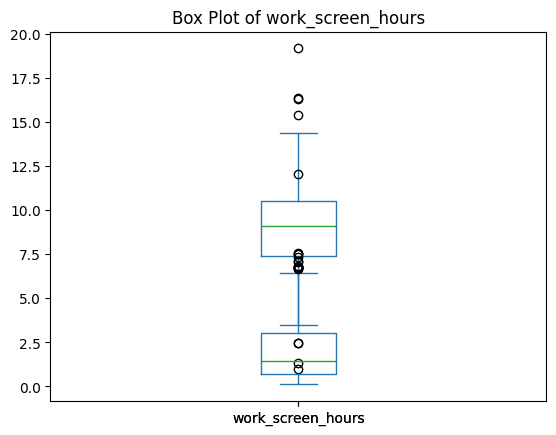

In [ ]:
df.describe()

# Check for outliers - screen time hours
q1 = np.percentile(df['screen_time_hours'], 25)
q3 = np.percentile(df['screen_time_hours'], 75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers = df['screen_time_hours'][(df['screen_time_hours'] < lower_bound) | (df['screen_time_hours'] > upper_bound)]
count_outliers = outliers.count()
print(f"Outliers using IQR: {count_outliers} \n{outliers}")
# There are 8 entries for Screen Time Hours falling outside the IQR

df['screen_time_hours'].plot(kind='box', title='Box Plot of screen_time_hours')
# We can see this in the box plot


## SHOW HOW SCREEN TIME IS THE SUM OF WORK/LIESURE SCREEN TIME


# Check for outliers - work screen hours
q1 = np.percentile(df['work_screen_hours'], 25)
q3 = np.percentile(df['work_screen_hours'], 75)
IQR = q3 - q1
lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR
outliers = df['work_screen_hours'][(df['work_screen_hours'] < lower_bound) | (df['work_screen_hours'] > upper_bound)]
count_outliers = outliers.count()
print(f"Outliers using IQR: {count_outliers} \n{outliers}")
# There are 15 entries for Screen Time Hours falling outside the IQR

df['work_screen_hours'].plot(kind='box', title='Box Plot of work_screen_hours')
# We can see this in the box plot


## SHOW HOW THE OUTLIER IS THE ONLY ONE THAT EXCEEDS 24 HRS IN A DAY ##




Outliers - Notes:

Age:
- All ages are reasonable.
- The youngest participant is 16. In the real world, I would check if it made sense to include minors in the analysis, or if they should be excluded

Screen Time Hours: 8 outliers
- All are technically possible, so I will leave them be for now.
- Upon exploration, I learned that Screen Time Hours is the sum of Work and Leisure Screen Hours. So the people with high-value outliers may use screens for work and play, and most of their waking hours would therefore be recorded in Screen Time Hours.

Work Screen Hours: 15 outliers
- This column is interesting because we can see a distinct split in the box plot where people either have a job sitting at a computer or they don't.
- Even still, we see 15 outliers using the IQR method.
- The one value most concerning to me is 12.04. Looking at that entry, the screen time and sleep time exceed the 24 hours in a day. This could be explained by taking liesure screen time on the clock, but we can't be sure.
- Upon further review, this entry is the only one to exceed 24 hours in a day, so this is a row that I would feel confident deleting. I would choose to do this for accuracy. That value could skew any analysis.

All integer values fall within the assigned bounds (ie - highest and lowest values for sleep quality are all between 1 and 5)

## Unnecessary Data

Look for the different types of unnecessary data in your dataset and address it as needed. Make sure to use code comments to illustrate your thought process.

## Inconsistent Data

Check for inconsistent data and address any that arises. As always, use code comments to illustrate your thought process.

## Summarize Your Results

Make note of your answers to the following questions.

1. Did you find all four types of dirty data in your dataset?
2. Did the process of cleaning your data give you new insights into your dataset?
3. Is there anything you would like to make note of when it comes to manipulating the data and making visualizations?